In [1]:
%pip install --quiet pmdarima statsmodels matplotlib pandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error

# **Part A — See what you have**
## **TASK 01 — Plot at three scales**

In [3]:
# Load data
df = pd.read_csv("retail_sales.csv", parse_dates=["date"]).set_index("date")
df = df.asfreq("D")

print(df.head())
print()
print("Shape:", df.shape)
print("Minimum:", df.index.min())
print("Maximum:", df.index.max())

              sales store_id  promo  temp_c
date                                       
2021-01-01  1298.13    ST001      1     8.2
2021-01-02  2257.93    ST001      0     5.3
2021-01-03  2116.99    ST001      1     7.8
2021-01-04  1677.36    ST001      0     0.1
2021-01-05  1818.43    ST001      0    11.6

Shape: (1461, 4)
Minimum: 2021-01-01 00:00:00
Maximum: 2024-12-31 00:00:00


In [4]:
# Check missing dates and values
full_dates = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

missing_dates = full_dates.difference(df.index)

print("Missing Dates:")
print(missing_dates)
print()
print("Missing Values:")
print(df.isna().sum())

Missing Dates:
DatetimeIndex([], dtype='datetime64[us]', freq='D')

Missing Values:
sales       6
store_id    0
promo       0
temp_c      0
dtype: int64


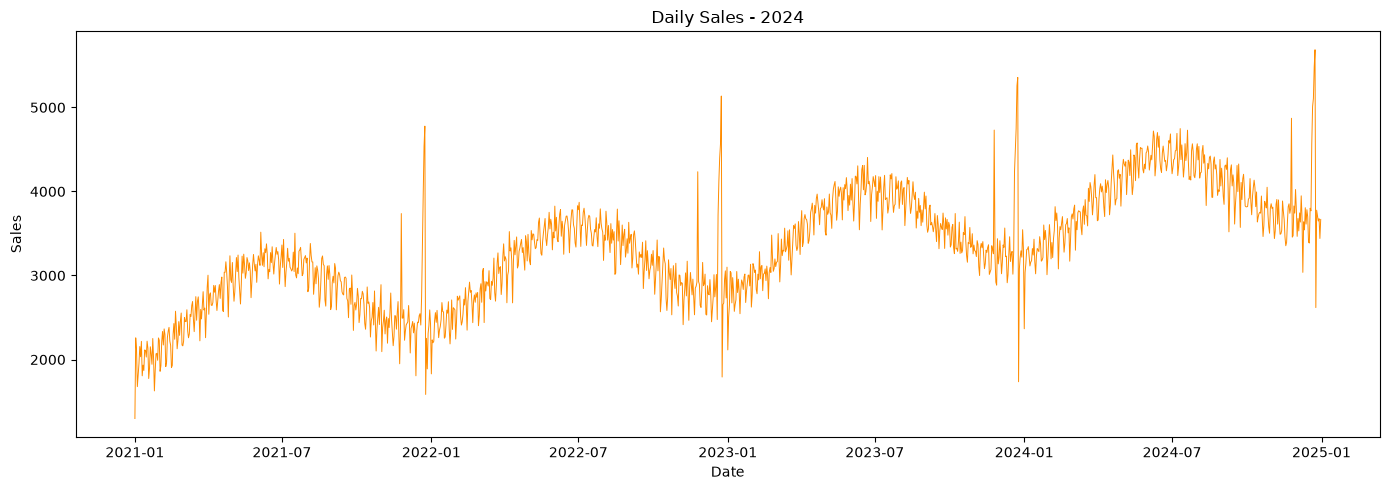

In [5]:
sales = df["sales"].interpolate(method="time")

# Plot full four years
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sales, color="darkorange", lw=0.7)

ax.set_title("Daily Sales - 2024")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

* The full series shows a clear long-term upward trend from 2021 to 2024.

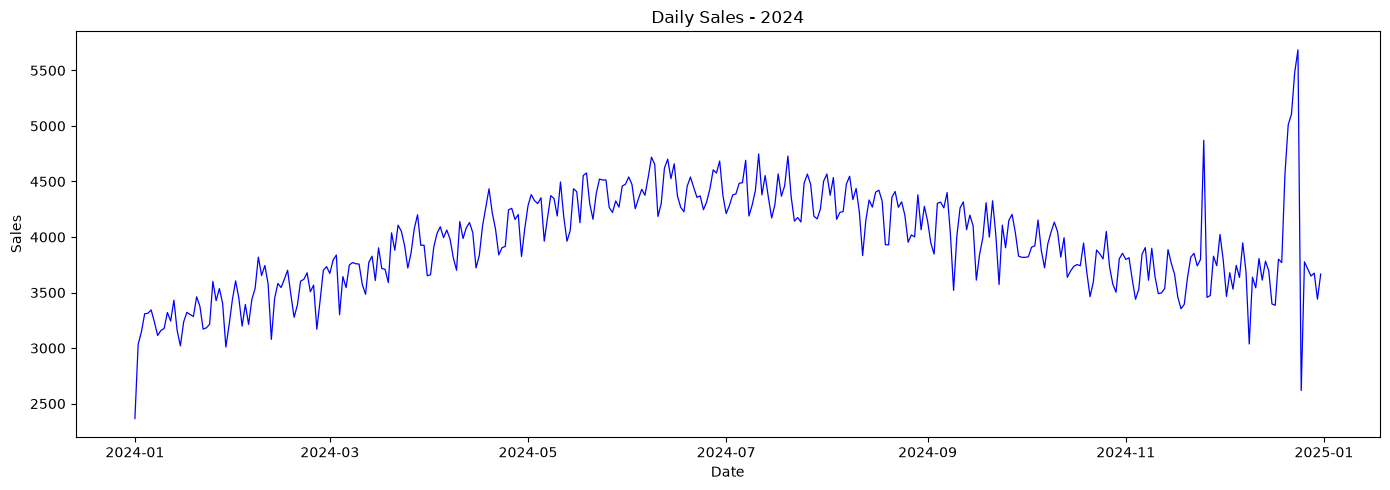

In [6]:
# Plot one year 
year_data = sales.loc["2024"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(year_data, color="blue", lw=0.9)

ax.set_title("Daily Sales - 2024")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

* At the yearly scale, shorter repeating fluctuations become visible on top of the upward trend.

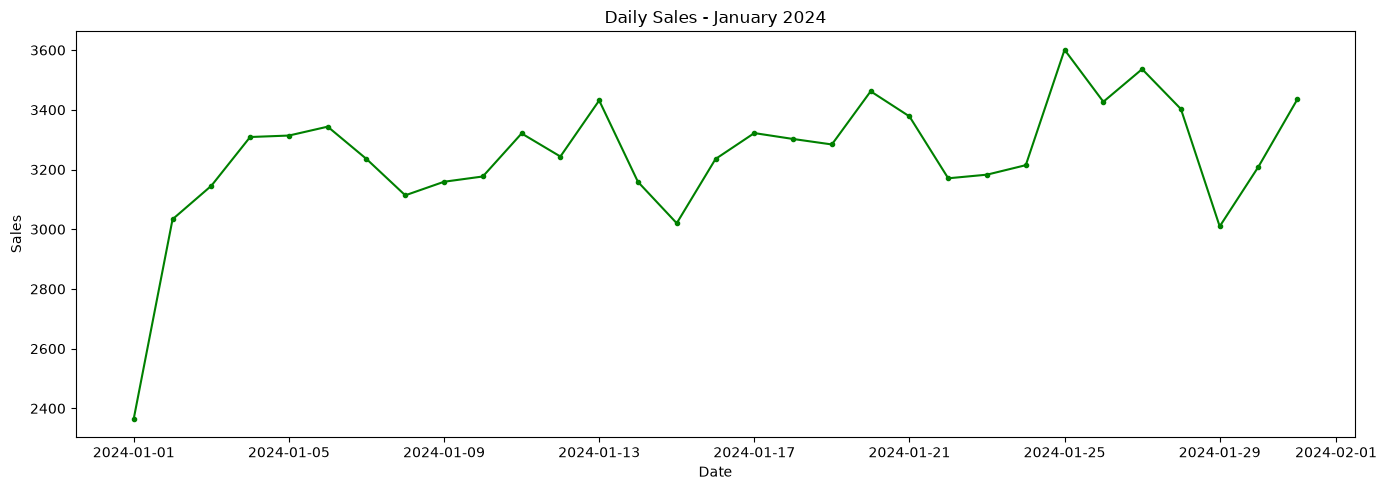

In [7]:
# One month
month_data = sales.loc["2024-01"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(month_data, color="green", marker="o", markersize=3)

ax.set_title("Daily Sales - January 2024")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

* At the monthly scale, individual day-to-day movements and the weekly pattern are much easier to see.

**Required Conclusion -->**
* The series contains a long-term yearly growth pattern, a repeating weekly cycle, and short-term daily variation. The four-year plot reveals the long-term trend, while the yearly and monthly plots make the shorter cycles easier to see.

## **TASK 02 — Handle the gaps correctly**

In [8]:
missing_sales = df[df["sales"].isna()]

print(missing_sales[["sales"]])

            sales
date             
2021-03-25    NaN
2021-12-02    NaN
2022-02-04    NaN
2023-08-16    NaN
2024-04-18    NaN
2024-12-27    NaN


In [9]:
# Three Methods
sales_mean = df["sales"].fillna(df["sales"].mean())

sales_ffill = df["sales"].ffill()

sales_interp = df["sales"].interpolate(method="time")

In [10]:
# Compare mean and standard deviation
fill_comparison = pd.DataFrame({
    "Mean": [
        sales_mean.mean(),
        sales_ffill.mean(),
        sales_interp.mean()
    ],
    "Standard Deviation": [
        sales_mean.std(),
        sales_ffill.std(),
        sales_interp.std()
    ]
}, index=["Overall Mean", "Forward Fill", "Interpolation"])

fill_comparison.round(2)

,Mean,Standard Deviation
Overall Mean,3328.27,644.25
Forward Fill,3327.79,645.82
Interpolation,3328.11,645.87


In [11]:
# Plot one gap
gap_date = df["sales"].first_valid_index()
gap_date = df[df["sales"].isna()].index[0]

window_start = gap_date - pd.Timedelta(days=7)
window_end = gap_date + pd.Timedelta(days=7)

window = pd.DataFrame({
    "Original": df["sales"],
    "Mean Fill": sales_mean,
    "Forward Fill": sales_ffill,
    "Interpolation": sales_interp
}).loc[window_start:window_end]

window.round(2)

,Original,Mean Fill,Forward Fill,Interpolation
date,,,,
2021-03-18,2466.92,2466.92,2466.92,2466.92
2021-03-19,2690.65,2690.65,2690.65,2690.65
2021-03-20,2745.65,2745.65,2745.65,2745.65
2021-03-21,2564.93,2564.93,2564.93,2564.93
2021-03-22,2222.45,2222.45,2222.45,2222.45
2021-03-23,2595.73,2595.73,2595.73,2595.73
2021-03-24,2483.27,2483.27,2483.27,2483.27
2021-03-25,NaN,3328.27,2483.27,2645.32
2021-03-26,2807.36,2807.36,2807.36,2807.36


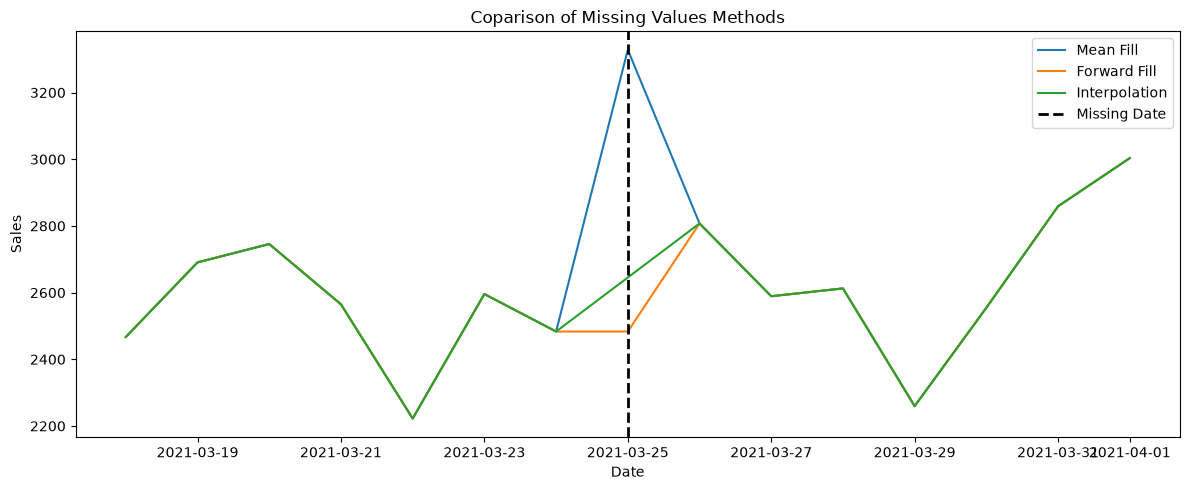

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(window.index, window["Mean Fill"], label="Mean Fill")
ax.plot(window.index, window["Forward Fill"], label="Forward Fill")
ax.plot(window.index, window["Interpolation"], label="Interpolation")

ax.axvline(gap_date, ls="--", label="Missing Date", color="black", lw=2)

ax.set_title("Coparison of Missing Values Methods")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

* The graph shows that the three methods produce different values at the missing date. Mean filling ignores the local time-series pattern and uses the overall average.
* Forward fill uses the previous observation.
* While interpolation uses the neighboring observations to estimate a value that better follows the local trend.

* I would use interpolation because it considers the ordering of the data and the values surrounding the missing date.
* I would use time-based interpolation because it uses the values immediately before and after the missing date. This respects the ordering of the time series, whereas the overall mean ignores when the missing value occurred.

# **Part B — Decompose and test**
## **TASK 03 — STL decomposition**

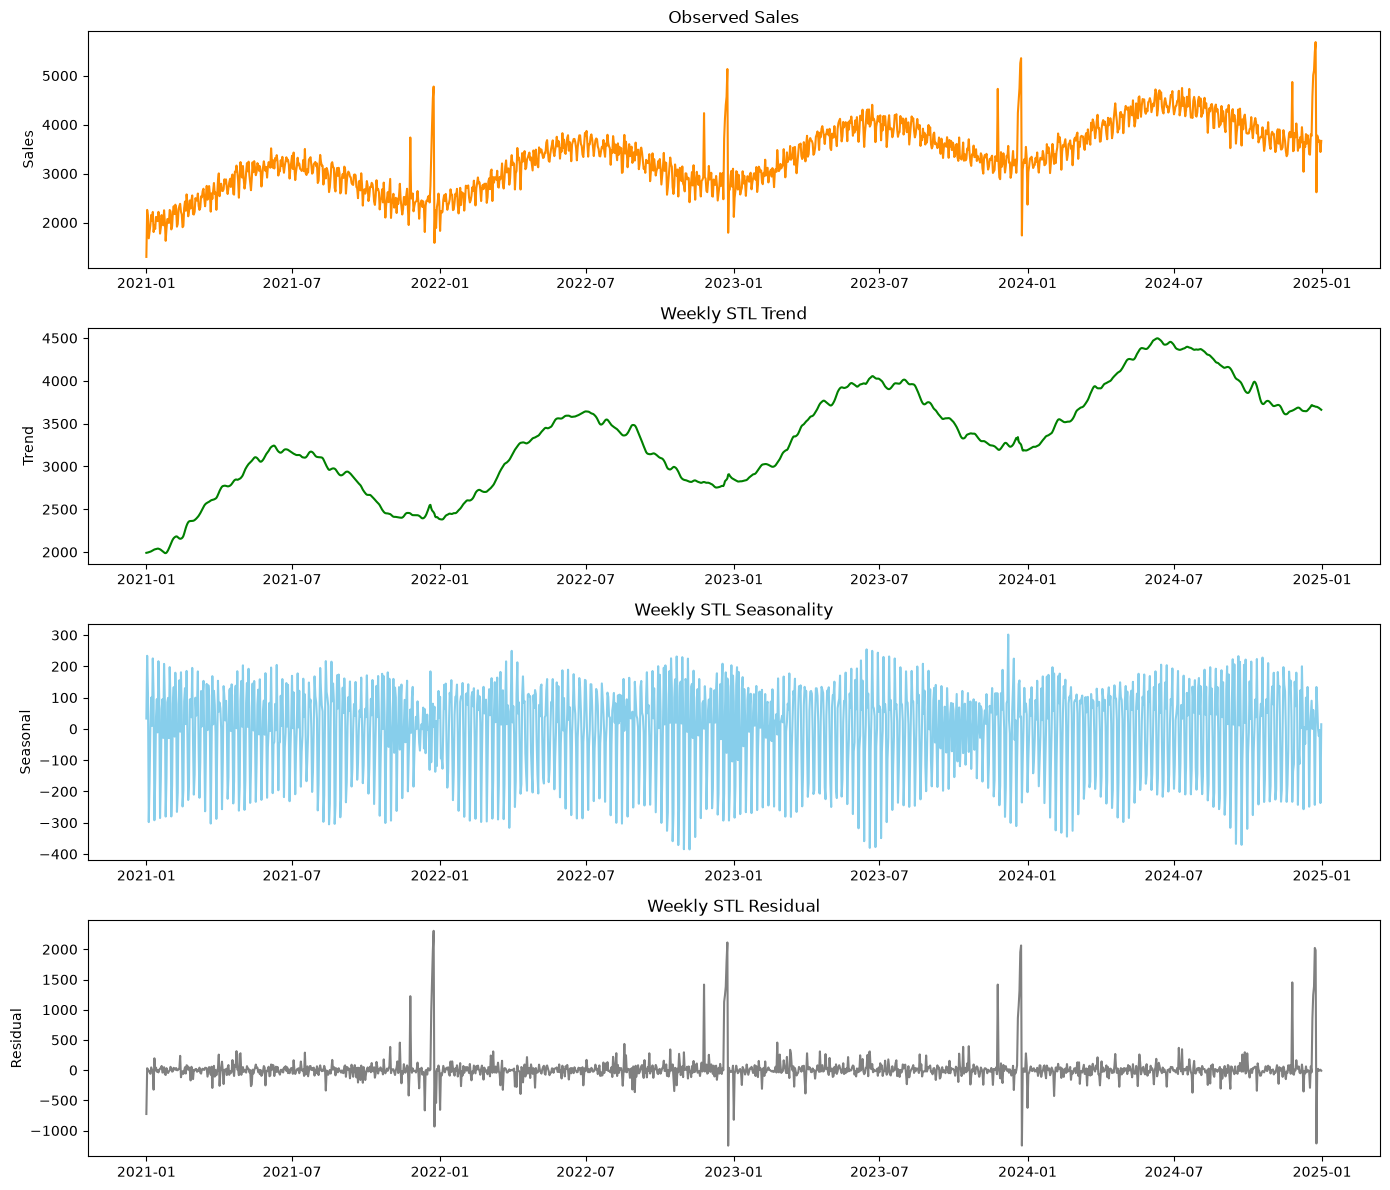

In [13]:
# weekly STL
stl_weekly = STL(sales, period=7, robust=True).fit()

# Plot all four components
fig, ax = plt.subplots(4, 1, figsize=(14, 12))

ax[0].plot(sales, color="darkorange")
ax[0].set_title("Observed Sales")
ax[0].set_ylabel("Sales")

ax[1].plot(stl_weekly.trend, color="green")
ax[1].set_title("Weekly STL Trend")
ax[1].set_ylabel("Trend")

ax[2].plot(stl_weekly.seasonal, color="skyblue")
ax[2].set_title("Weekly STL Seasonality")
ax[2].set_ylabel("Seasonal")

ax[3].plot(stl_weekly.resid, color="gray")
ax[3].set_title("Weekly STL Residual")
ax[3].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [14]:
# Component statistics
components = pd.DataFrame({
    "Range": [
        stl_weekly.trend.max() - stl_weekly.trend.min(),
        stl_weekly.seasonal.max() - stl_weekly.seasonal.min(),
        stl_weekly.resid.max() - stl_weekly.resid.min()
    ],
    "Std.": [
        stl_weekly.trend.std(),
        stl_weekly.seasonal.std(),
        stl_weekly.resid.std()
    ]
}, index=["Trend", "Seasonality", "Residual"])

components.round(2)

,Range,Std.
Trend,2509.83,591.91
Seasonality,686.82,138.93
Residual,3555.39,230.35


In [15]:
# Variance Explained 
total_variance = sales.var()

trend_variance = stl_weekly.trend.var()
seasonal_variance = stl_weekly.seasonal.var()

variance_fraction = (trend_variance + seasonal_variance) / total_variance

print("Variance Explained by trend + seasonality:",
     variance_fraction.round(3))

Variance Explained by trend + seasonality: 0.886


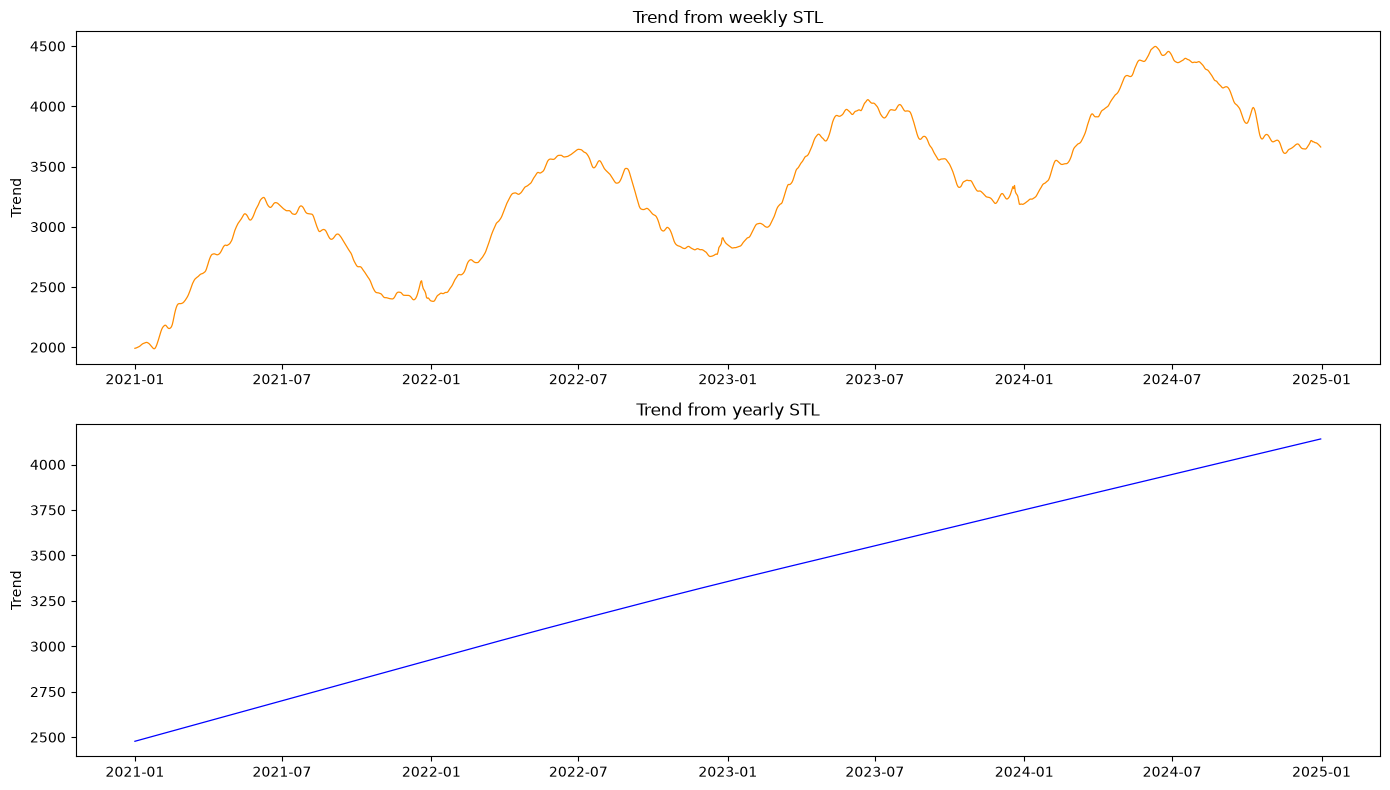

In [16]:
# Yearly STL
stl_yearly = STL(sales, period=365, robust=True).fit()

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

ax[0].plot(stl_weekly.trend, color="darkorange", lw=0.9)
ax[0].set_title("Trend from weekly STL")
ax[0].set_ylabel("Trend")

ax[1].plot(stl_yearly.trend, color="blue", lw=0.9)
ax[1].set_title("Trend from yearly STL")
ax[1].set_ylabel("Trend")

plt.tight_layout()
plt.show()

* STL does not automatically decide which cycle I want. I tell STL which cycle to investigate by specifying the period. With period=7, STL focuses on the weekly cycle, while period=365 allows the yearly pattern to be represented. Therefore, the same series can produce different decompositions.

## **TASK 04 — Test for stationarity**

In [18]:
# Raw series
adf_raw = adfuller(sales)

print("ADF Statistic:", adf_raw[0].round(3))
print("p-value:", adf_raw[1].round(3))

ADF Statistic: -2.154
p-value: 0.223


**Interpretation**
* The p-value is greater than 0.05, so I fail to reject the null hypothesis.
* The raw sales series is therefore not stationary according to the ADF test.

In [24]:
# First difference
sales_diff = sales.diff().dropna()
adf_diff = adfuller(sales_diff)

print("ADF Statistic:", adf_diff[0].round(3))
print(f"p-value: {adf_diff[1]}")

ADF Statistic: -11.626
p-value: 2.324807265935953e-21


In [26]:
# Seasonal Difference
sales_season = sales.diff(7).dropna()
adf_season = adfuller(sales_season)

print("ADF Statistic:", adf_season[0].round(3))
print("p-value:", adf_season[1])

ADF Statistic: -8.503
p-value: 1.224229772981578e-13


In [27]:
# STL Residual
stl_resi = stl_weekly.resid.dropna()
adf_resi = adfuller(stl_resi)

print("ADF Statistic:", adf_resi[0].round(3))
print("p-value:", adf_resi[1])

ADF Statistic: -12.658
p-value: 1.3220916757082519e-23


In [32]:
# Put all four together
adf_results = pd.DataFrame({
    "Series": ["Raw", "First Difference", "Seasonal Difference",
              "STL Residual"],
    "ADF Statistic": [adf_raw[0], adf_diff[0], adf_season[0],
                     adf_resi[0]],
    "p_value": [adf_raw[1], adf_diff[1], adf_season[1],
               adf_resi[1]]
})

adf_results.style.hide(axis="index")

Series,ADF Statistic,p_value
Raw,-2.154416,0.223204
First Difference,-11.625844,0.000000
Seasonal Difference,-8.502956,0.000000
STL Residual,-12.658262,0.000000


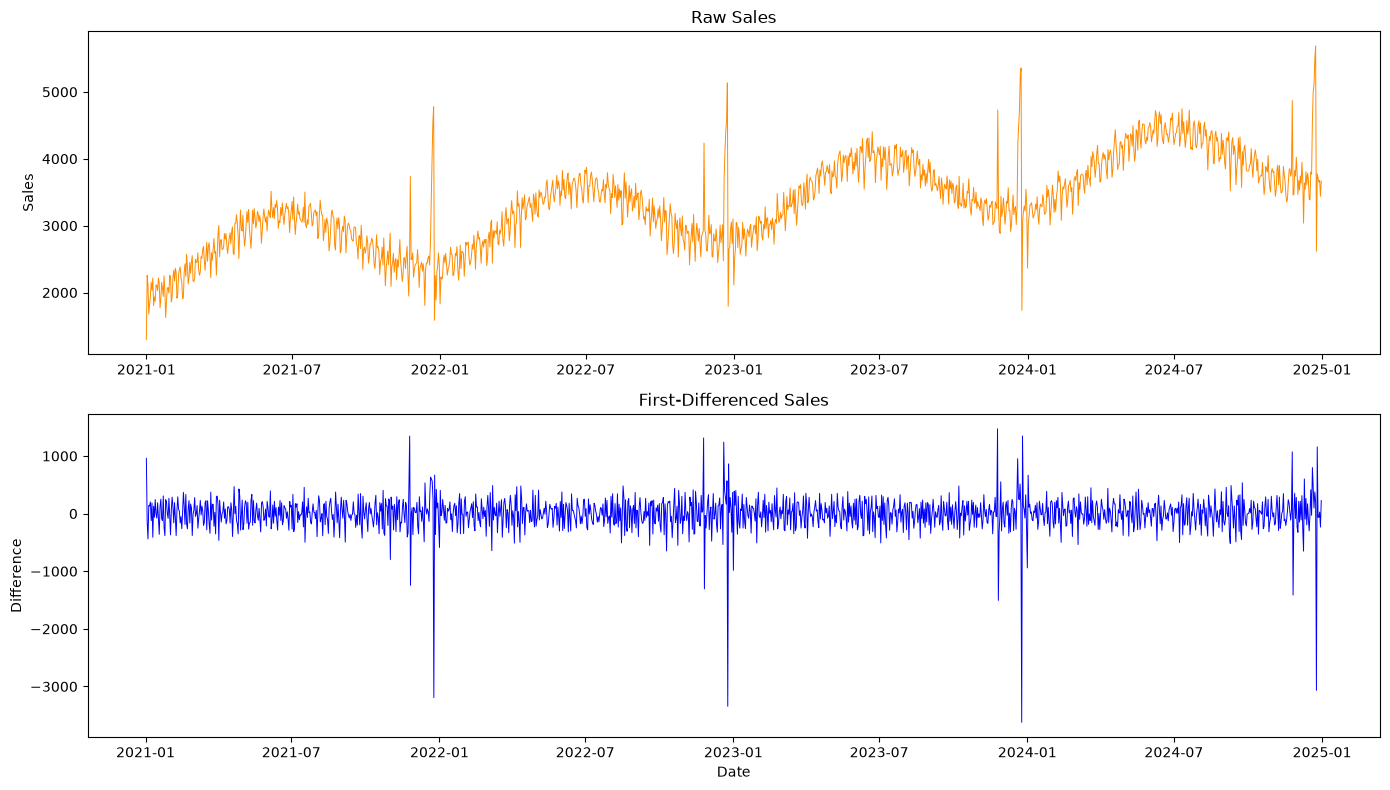

In [34]:
# Plot Raw vs Differenced
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

ax[0].plot(sales, color="darkorange", lw=0.7)
ax[0].set_title("Raw Sales")
ax[0].set_ylabel("Sales")

ax[1].plot(sales_diff, color="blue", lw=0.7)
ax[1].set_title("First-Differenced Sales")
ax[1].set_ylabel("Difference")
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

**ADF Null Hypothesis:**
* `H0`: The time series has a unit root and is non-stationary.

`Therefore:`
* p-value < 0.05 → reject H0 → evidence of stationarity
* p-value >= 0.05 → fail to reject H0 → evidence of non-stationarity

## **TASK 05 — Read the autocorrelation**

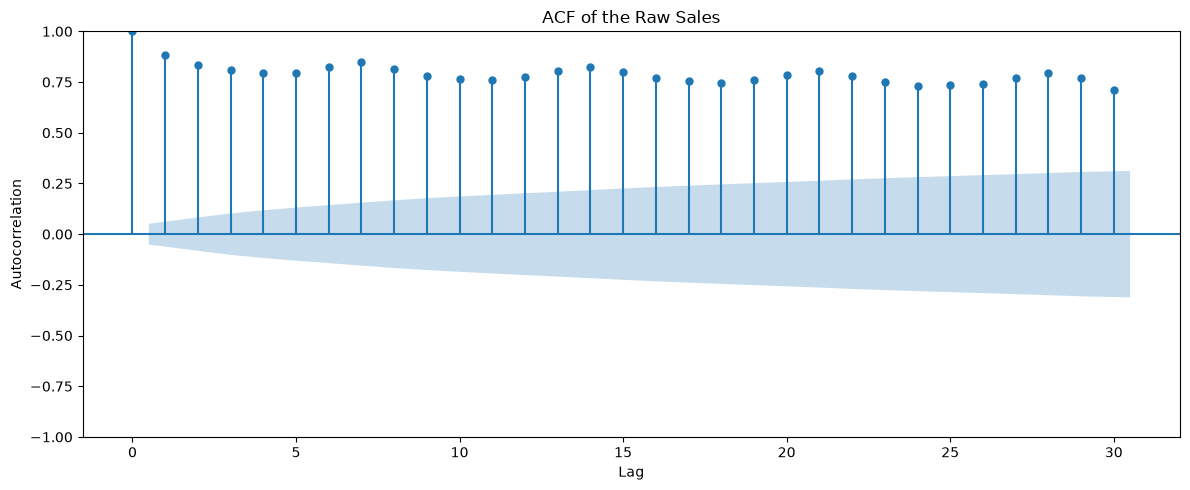

In [40]:
# Raw ACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(sales, lags=30, ax=ax)
ax.set_title("ACF of the Raw Sales")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [42]:
# print lags 1 - 14
acf_values = acf(sales, nlags=30)

for lag in range(1, 15):
    print(f"Lag {lag}: {acf_values[lag]:.4f}")

Lag 1: 0.8851
Lag 2: 0.8347
Lag 3: 0.8115
Lag 4: 0.7932
Lag 5: 0.7921
Lag 6: 0.8247
Lag 7: 0.8508
Lag 8: 0.8126
Lag 9: 0.7816
Lag 10: 0.7640
Lag 11: 0.7587
Lag 12: 0.7728
Lag 13: 0.8029
Lag 14: 0.8243


In [43]:
# Count values above 0.5
count_above_05 = np.sum(acf_values[1:] > 0.5)

print("Number of lags above 0.5:", count_above_05)

Number of lags above 0.5: 30


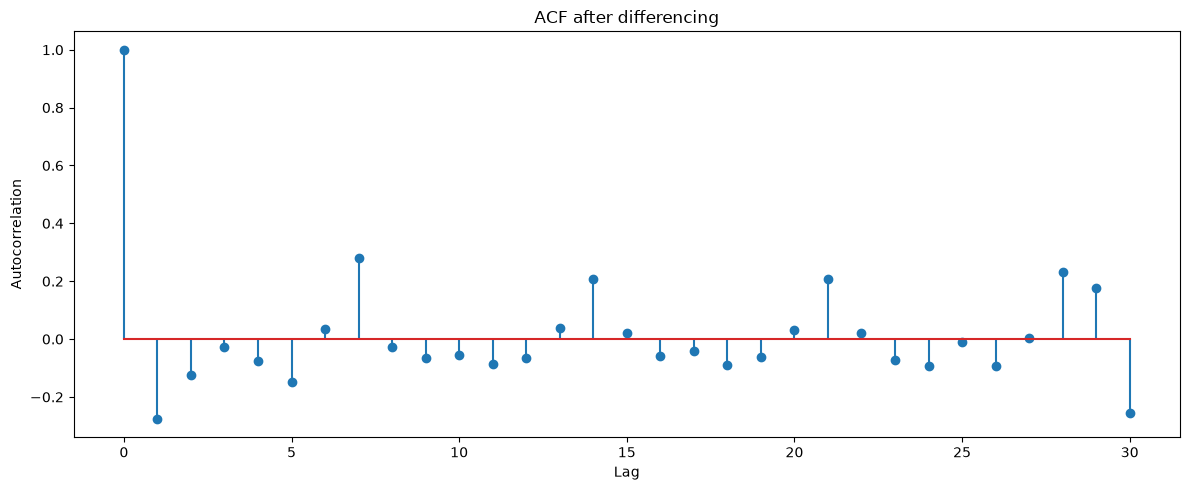

In [44]:
# Difference and plot the acf again
acf_diff = acf(sales_diff, nlags=30)

fig, ax = plt.subplots(figsize=(12, 5))

ax.stem(range(31), acf_diff)

ax.set_title("ACF after differencing")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [46]:
# lag 7
print("Lag 7 before differencing:",
     acf_raw[7].round(3))
print("Lag 7 after differencing:",
     acf_diff[7].round(3))

Lag 7 before differencing: 0.851
Lag 7 after differencing: 0.279


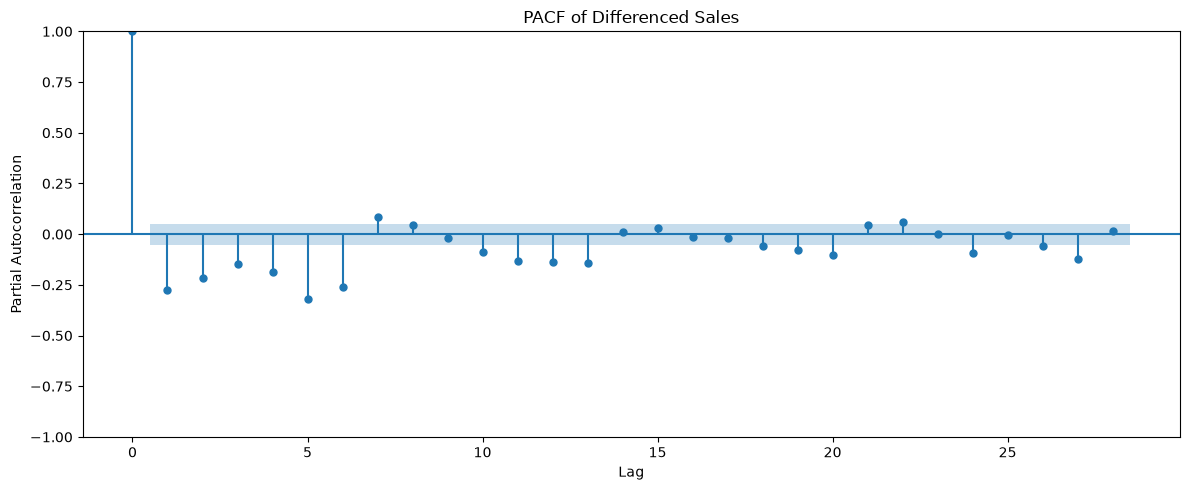

In [48]:
# PACF
fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(sales_diff, lags=28, ax=ax, method="ywm")
ax.set_title("PACF of Differenced Sales")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

**Conclusion -->**
* The raw ACF is high at nearly every lag because the series contains a strong trend and seasonal structure.
* When a series is non-stationary, I should difference it before using the ACF to choose meaningful lag relationships.

**ACF VS PACF -->**
* ACF measures the correlation between the series and its lagged values, including indirect relationships.
* PACF measures the relationship with a lag after removing the effects of the shorter lags.
* For selecting lag features, PACF is more useful because it helps identify which individual lags provide direct additional information.

# **Part C — Build features without leaking**
## **TASK 06 — Lag and rolling features**

In [58]:
df_features = df.copy()
df_features["sales"] = df_features["sales"].interpolate()

for lag in [1, 2, 7, 14, 28]:
    df_features[f"lag_{lag}"] = df_features["sales"].shift(lag)

df_features.head(10)

,sales,store_id,promo,temp_c,lag_1,lag_2,lag_7,lag_14,lag_28
date,,,,,,,,,
2021-01-01,1298.13,ST001,1,8.2,NaN,NaN,NaN,NaN,NaN
2021-01-02,2257.93,ST001,0,5.3,1298.13,NaN,NaN,NaN,NaN
2021-01-03,2116.99,ST001,1,7.8,2257.93,1298.13,NaN,NaN,NaN
2021-01-04,1677.36,ST001,0,0.1,2116.99,2257.93,NaN,NaN,NaN
2021-01-05,1818.43,ST001,0,11.6,1677.36,2116.99,NaN,NaN,NaN
2021-01-06,1951.42,ST001,1,4.6,1818.43,1677.36,NaN,NaN,NaN
2021-01-07,2154.47,ST001,0,7.9,1951.42,1818.43,NaN,NaN,NaN
2021-01-08,2033.03,ST001,0,7.2,2154.47,1951.42,1298.13,NaN,NaN
2021-01-09,2216.37,ST001,0,6.5,2033.03,2154.47,2257.93,NaN,NaN


In [59]:
# Rolling features
df_features["rolling_7"] = df_features["sales"].shift(1).rolling(7).mean()
df_features["rolling_28"] = df_features["sales"].shift(1).rolling(28).mean()

df_features.head(10)

,sales,store_id,promo,temp_c,lag_1,lag_2,lag_7,lag_14,lag_28,rolling_7,rolling_28
date,,,,,,,,,,,
2021-01-01,1298.13,ST001,1,8.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,2257.93,ST001,0,5.3,1298.13,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,2116.99,ST001,1,7.8,2257.93,1298.13,NaN,NaN,NaN,NaN,NaN
2021-01-04,1677.36,ST001,0,0.1,2116.99,2257.93,NaN,NaN,NaN,NaN,NaN
2021-01-05,1818.43,ST001,0,11.6,1677.36,2116.99,NaN,NaN,NaN,NaN,NaN
2021-01-06,1951.42,ST001,1,4.6,1818.43,1677.36,NaN,NaN,NaN,NaN,NaN
2021-01-07,2154.47,ST001,0,7.9,1951.42,1818.43,NaN,NaN,NaN,NaN,NaN
2021-01-08,2033.03,ST001,0,7.2,2154.47,1951.42,1298.13,NaN,NaN,1896.390000,NaN
2021-01-09,2216.37,ST001,0,6.5,2033.03,2154.47,2257.93,NaN,NaN,2001.375714,NaN


In [60]:
# creating calendar features
df_features["days_of_week"] = df_features.index.dayofweek
df_features["month"] = df_features.index.month
df_features["day_of_year"] = df_features.index.dayofyear

df_features.head()

,sales,store_id,promo,temp_c,lag_1,lag_2,lag_7,lag_14,lag_28,rolling_7,rolling_28,days_of_week,month,day_of_year
date,,,,,,,,,,,,,,
2021-01-01,1298.13,ST001,1,8.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1
2021-01-02,2257.93,ST001,0,5.3,1298.13,NaN,NaN,NaN,NaN,NaN,NaN,5,1,2
2021-01-03,2116.99,ST001,1,7.8,2257.93,1298.13,NaN,NaN,NaN,NaN,NaN,6,1,3
2021-01-04,1677.36,ST001,0,0.1,2116.99,2257.93,NaN,NaN,NaN,NaN,NaN,0,1,4
2021-01-05,1818.43,ST001,0,11.6,1677.36,2116.99,NaN,NaN,NaN,NaN,NaN,1,1,5


In [61]:
# Removes rows containing NaN
before_rows = len(df_features)

model_data = df_features.dropna()

after_rows = len(model_data)

print("Rows Before:", before_rows)
print("Rows After:", after_rows)
print("Rows Lost:", before_rows - after_rows)

Rows Before: 1461
Rows After: 1433
Rows Lost: 28


In [62]:
rolling_wrong = df_features["sales"].rolling(7).mean()
rolling_correct = df_features["sales"].shift(1).rolling(7).mean()

# Compare them
leak_demo = pd.DataFrame({
    "Sales": df_features["sales"],
    "Wrong_rolling_mean": rolling_wrong,
    "Correct_rolling_mean": rolling_correct
})

print(leak_demo.iloc[30:40])

              Sales  Wrong_rolling_mean  Correct_rolling_mean
date                                                         
2021-01-31  2229.18         2016.264286           1984.941429
2021-02-01  1859.82         2049.581429           2016.264286
2021-02-02  1925.10         2057.611429           2049.581429
2021-02-03  2211.16         2078.050000           2057.611429
2021-02-04  2333.73         2115.225714           2078.050000
2021-02-05  2172.83         2141.231429           2115.225714
2021-02-06  2364.35         2156.595714           2141.231429
2021-02-07  2297.62         2166.372857           2156.595714
2021-02-08  1915.88         2174.381429           2166.372857
2021-02-09  1971.33         2180.985714           2174.381429


`Wrong rolling:`  
includes today's sales.

`Correct rolling:`  
uses only previous sales.

* Python gives no error because both expressions are valid pandas operations.
* The problem is not a syntax error; it is data leakage.
* The unshifted rolling mean contains information from today's target, so validation can look artificially excellent even though that information would not be available when making a real prediction.

# **Part D — Evaluate honestly**
## **TASK 07 — Establish baselines FIRST**

In [66]:
# Overall Mean
mean_prediction = pd.Series(sales.mean(), index=sales.index)

valid = sales.notna() & mean_prediction.notna()

mean_mae = mean_absolute_error(sales[valid], mean_prediction[valid])

print("Mean baseline MAE:", round(mean_mae, 2))

Mean baseline MAE: 522.99


In [69]:
# Yesterday's value
naive_prediction = sales.shift(1)

valid = sales.notna() & naive_prediction.notna()

naive_mae = mean_absolute_error(sales[valid], naive_prediction[valid])

print("Naive baseline MAE:", round(naive_mae, 2))

Naive baseline MAE: 195.79


In [70]:
# Same day last week
seasonal_naive_prediction = sales.shift(7)

valid = sales.notna() & seasonal_naive_prediction.notna()

seasonal_naive_mae = mean_absolute_error(sales[valid], seasonal_naive_prediction[valid])

print("Seasonal naive MAE:", round(seasonal_naive_mae, 2))

Seasonal naive MAE: 180.5


* The seasonal-naive forecast is the strongest baseline because sales have a strong weekly pattern. Predicting the same day's sales from the previous week therefore uses information that is highly relevant to this series.

## **TASK 08 — Two evaluations, one model**

In [74]:
X = model_data.drop(columns=["sales", "store_id"])
y = model_data["sales"]

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (1433, 12)
Y Shape: (1433,)


In [77]:
# Random KFold
model = RandomForestRegressor(n_estimators=200, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("KFold MAE for each fold:")
print(kf_scores.round(2))
print()
print("KFold Mean MAE:")
print(kf_scores.mean().round(2))

KFold MAE for each fold:
[128.96 137.62 139.58 135.06 149.91]

KFold Mean MAE:
138.22


In [80]:
# Time series split
tscv = TimeSeriesSplit(n_splits=5)

timeseries_score = -cross_val_score(model, X, y, cv=tscv, scoring="neg_mean_absolute_error")

print("TimeSeriesSplit MAE for each fold:")
print(timeseries_score.round(2))
print()
print("TimeSeriesSplit Mean MAE:")
print(timeseries_score.mean().round(2))

TimeSeriesSplit MAE for each fold:
[191.9  171.39 208.16 160.22 208.36]

TimeSeriesSplit Mean MAE:
188.01


In [81]:
# Compare everything
comparison = pd.DataFrame({
    "Method": ["Overall Mean", "Naive", "Seasonal Naive",
              "Random KFold", "TimeSeriesSplit"],
    "MAE": [mean_mae, naive_mae, seasonal_naive_mae, kf_scores.mean(),
           timeseries_score.mean()]
})

comparison.round(2)

,Method,MAE
0,Overall Mean,522.99
1,Naive,195.79
2,Seasonal Naive,180.50
3,Random KFold,138.22
4,TimeSeriesSplit,188.01


In [84]:
# Feature Importance
model.fit(X, y)

feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

feature_importance.round(3)

lag_1           0.388
rolling_7       0.245
lag_7           0.151
rolling_28      0.081
lag_14          0.059
day_of_year     0.032
lag_2           0.014
lag_28          0.014
days_of_week    0.007
temp_c          0.006
month           0.003
promo           0.001
dtype: float64

**Required Conclusion ->**
* The random KFold evaluation suggests that the Random Forest beats the seasonal-naive baseline because its MAE is about 138.22 compared with 180.50.
* However, I do not trust this result for deployment because random KFold mixes observations from different points in time. The model can therefore learn patterns from future periods while predicting earlier periods.
* TimeSeriesSplit respects chronological ordering and gives an MAE of about 188.01, which is worse than the seasonal-naive baseline of 180.50.
* Therefore, the seasonal-naive baseline is currently the better choice.

**Why random split is misleading -->**
* Random KFold measured how well the model predicts randomly selected historical observations when information from other time periods is available during training.
* It did not simulate the real forecasting situation where the model only has access to the past and must predict the future.

**Random Forest problem with growing series**
* A Random Forest cannot predict outside the range of the target values seen during training. Therefore, if sales continue growing, a future period may contain values larger than anything seen during training, which makes this limitation particularly important.

## **TASK 09 — Investigate the external columns**

In [88]:
# Promo days vs non promo days 
promo_sales = pd.DataFrame({
    "sales": sales,
    "promo": df["promo"]
})

promo_means = promo_sales.groupby("promo")["sales"].mean()

print(promo_means.round(2))

promo_difference = (promo_means.loc[1] - 
                   promo_means.loc[0])

print("Difference:", promo_difference.round(2))

promo
0    3330.59
1    3314.41
Name: sales, dtype: float64
Difference: -16.19


In [90]:
# Raw temprature-sales correlation
temperature = df["temp_c"].interpolate(method="time")
raw_correlation = sales.corr(temperature)

print("Raw Correlation:", raw_correlation.round(3))

Raw Correlation: 0.491


In [93]:
# Remove weekly seasonality from sales
sales_stl = STL(sales, period=7, robust=True).fit()
sales_resi = sales_stl.resid

# Remove weekly seasonality from temperature
temp_stl = STL(temperature, period=7, robust=True).fit()
temp_resi = temp_stl.resid

# correlation after removing seasonality
deseasonal_corr = (sales_resi.corr(temp_resi))

print("Raw Correlation:",
     raw_correlation.round(3))
print("Deseasonalized Correlation:",
     deseasonal_corr.round(3))

Raw Correlation: 0.491
Deseasonalized Correlation: 0.06


In [95]:
# Compare side by side
comparison = pd.DataFrame({
    "Correlation": [raw_correlation,
                   deseasonal_corr]
}, index=["Raw", 
         "After Removing weekly seasonality"])

comparison.round(3)

,Correlation
Raw,0.491
After Removing weekly seasonality,0.060


**Conclusion -->**
* Promo carries almost no useful signal in this dataset because the average sales on promo days are only about 16 units lower than non-promo days, which is very small relative to the overall sales variation.
* Temperature appears moderately correlated with sales at first (about 0.49), but after removing the shared weekly seasonal pattern the correlation falls to about 0.06. This means most of the original correlation was caused by shared seasonal structure rather than a strong independent relationship.
* Therefore, promo saves us from adding an unnecessary feature, while temperature should not automatically be treated as a strong predictor without further evidence.

### **Final Conclusion -->**
* The retail sales series contains a strong upward trend and a clear weekly seasonal pattern.
* The raw series is non-stationary according to the ADF test, while the differenced series and STL residual are stationary.
* The seasonal-naive baseline achieved an MAE of approximately 180.50.
* Random KFold gave an MAE of approximately 138.22, but this evaluation is not trustworthy for future forecasting because it mixes past and future observations.
* TimeSeriesSplit gave an MAE of approximately 188.01, which is worse than the seasonal-naive baseline.
* Therefore, the seasonal-naive forecast is currently the better model to deploy.
* The main lesson is that time-series data must be evaluated chronologically and that a model must beat a strong time-aware baseline before it should be considered useful.